In [1]:
%load_ext autoreload
%autoreload 2

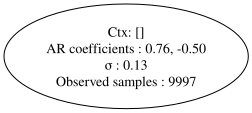

In [69]:
## We generate a standard AR model and try to fit a LiveARTree on it
import numpy as np
from ctw.models import LiveARTree, Quantizer
from ctw.tree import view_tree, view_tree_debug
from ctw.series import AR

# Parameters
np.random.seed(0)
order = 2
coefficients = [0.75, -0.5]
noise_std = 0.1
n_samples = 500
quantization_levels = 16
max_depth = 3

# Generate synthetic AR time series data
ar_model = AR(order, coefficients, noise_std, n_sample=10000)
data = [x for x in ar_model]

# Initialize quantizer
data_min, data_max = min(data), max(data)
thresholds = np.linspace(data_min, data_max, quantization_levels)
quantizer = Quantizer(thresholds)

# Initialize and fit LiveARTree model
live_ar_tree = LiveARTree(order=order, max_depth=max_depth, quantizer=quantizer, beta=0.5)
for x in data :
    live_ar_tree.observe(x)

# Visualize the resulting tree
view_tree(live_ar_tree.tree)


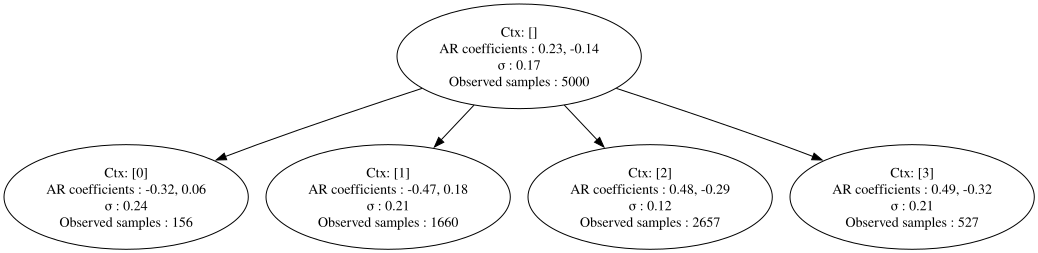

In [ ]:
## Create a custom dual AR model and fit a LiveARTree on it (the value depends on the value 1 step back)
from ctw.tree import Tree, TreeNode, view_tree
import numpy as np
from matplotlib import pyplot as plt
from ctw.models import Quantizer

## Parameters
positive_ar_coeff = [0.5, -0.3]
positive_var = 0.1

negative_ar_coeff = [-0.4, 0.2]
negative_var = 0.2

def generate_dual_ar(init_seq = [0.0, 0.0], n_samples=1000) :
    x = init_seq[:]
    for i in range(n_samples) :
        if x[-1] > 0 :
            x.append(positive_ar_coeff[0]*x[-1] + positive_ar_coeff[1]*x[-2] + np.random.normal(0, positive_var))
        else :
            x.append(negative_ar_coeff[0]*x[-1] + negative_ar_coeff[1]*x[-2] + np.random.normal(0, negative_var))
    return x

data = generate_dual_ar(n_samples=5000)
thresholds = [-0.25, 0.0, 0.25, 0.5]
quantizer = Quantizer(thresholds)

live_ar_tree = LiveARTree(order=2, max_depth=2, quantizer=quantizer, beta=0.9)
for x in data :
    live_ar_tree.observe(x)

view_tree(live_ar_tree.tree)

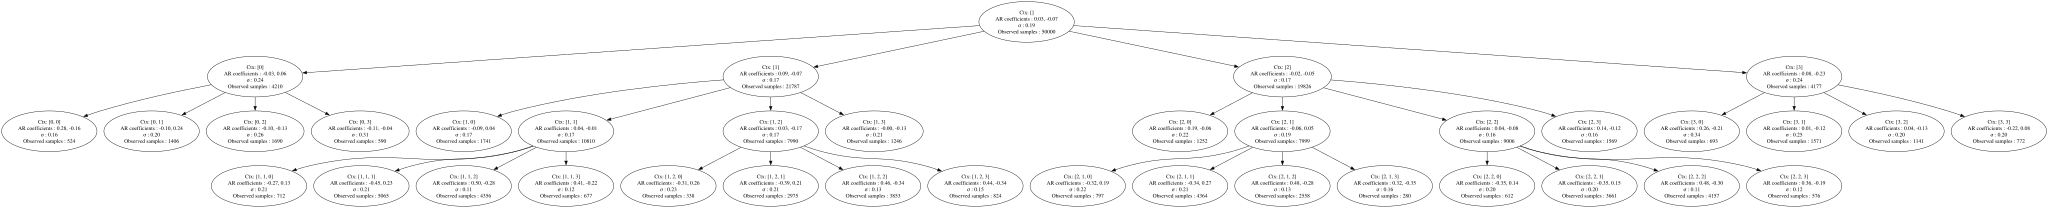

In [ ]:
## This time , the AR model depends on the value 3 steps back
from ctw.tree import Tree, TreeNode, view_tree
import numpy as np
from matplotlib import pyplot as plt
from ctw.models import Quantizer

## Parameters
positive_ar_coeff = [0.5, -0.3]
positive_var = 0.1

negative_ar_coeff = [-0.4, 0.2]
negative_var = 0.2

def generate_dual_ar(init_seq = [0.0, 0.0, 0.0], n_samples=1000) :
    x = init_seq[:]
    for i in range(n_samples) :
        if x[-3] > 0 :
            x.append(positive_ar_coeff[0]*x[-1] + positive_ar_coeff[1]*x[-2] + np.random.normal(0, positive_var))
        else :
            x.append(negative_ar_coeff[0]*x[-1] + negative_ar_coeff[1]*x[-2] + np.random.normal(0, negative_var))
    return x

data = generate_dual_ar(n_samples=50000)
thresholds = [-0.25, 0.0, 0.25, 0.5]
quantizer = Quantizer(thresholds)

live_ar_tree = LiveARTree(order=2, max_depth=3, quantizer=quantizer, beta=0.5)
for x in data :
    live_ar_tree.observe(x)

view_tree(live_ar_tree.tree)
## We see that the tree is deeper and is able to capture the dependency on the value 3 steps back

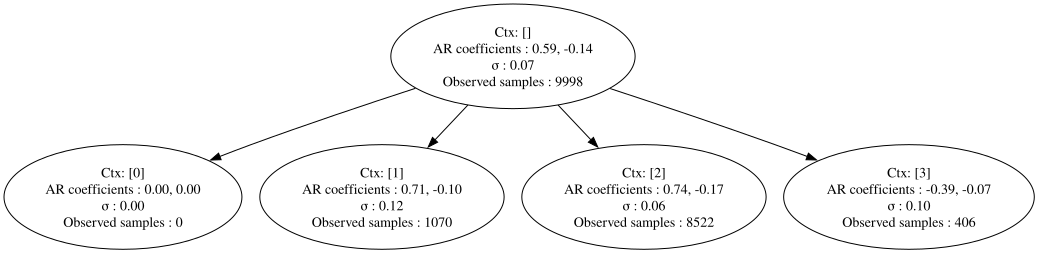

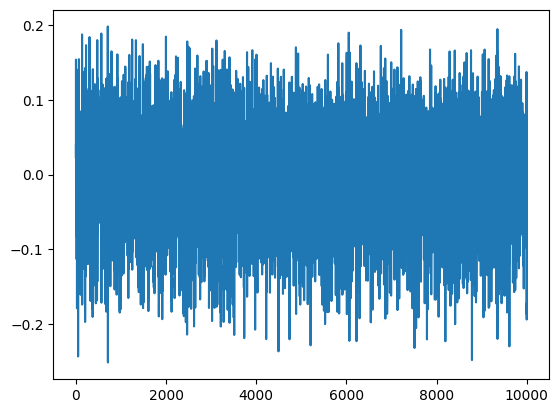

In [82]:
## Try to fit SETAR data
from ctw.tree import Tree, TreeNode, view_tree
from ctw.models import ARTree, Quantizer
from matplotlib import pyplot as plt
import numpy as np

def generate_setar_data(n_samples=2000, threshold=0.0, delay=1, sigma=0.1):
    """
    Generates data from a 2-regime SETAR model.
    Regime 1 (Low): x_t = 0.8 * x_{t-1} - 0.2 * x_{t-2} + eps
    Regime 2 (High): x_t = -0.5 * x_{t-1} + eps
    """
    p = 2  # Max order
    x = np.zeros(n_samples + p)
    
    # Coefficients for the two regimes
    phi_low = np.array([0.8, -0.2])
    phi_high = np.array([-0.5, 0.0]) # AR(1) effectively
    
    for t in range(p, n_samples + p):
        z_t = x[t - delay]
        
        noise = np.random.normal(0, sigma)
        
        if z_t <= threshold:
            # Regime 1 logic
            x[t] = phi_low[0] * x[t-1] + phi_low[1] * x[t-2] + noise
        else:
            # Regime 2 logic
            x[t] = phi_high[0] * x[t-1] + phi_high[1] * x[t-2] + noise
            
    return x[p:]

# Generate and visualize
setar_series = generate_setar_data(n_samples=10000, threshold=0.1, sigma=0.05)
plt.plot(setar_series)

quantizer = Quantizer(thresholds=np.linspace(-0.3, 0.3, 4))
live_ar_tree = LiveARTree(order=2, max_depth=2, quantizer=quantizer, beta=0.5)
for x in setar_series:
    live_ar_tree.observe(x)

view_tree(live_ar_tree.tree)